# **02 - Exploratory Data Analysis (EDA)**

This notebook covers:
1. ODS label distribution and class imbalance
2. Multilabel complexity metrics (label cardinality, label density)
3. Text length analysis
4. ODS label co-occurrence
5. Text quality and OCR artefact detection
6. Summary

### **0. Imports & Configuration**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import sys
import os
from collections import Counter
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

sys.path.append('../src')
from utils import OUTPUT_DIR, OUTPUT_DIR_EDA, ODS_ALL, ODS_COLORS
from schema import Metadata

# Create analysis output directory if it does not exist
os.makedirs(OUTPUT_DIR_EDA, exist_ok=True)

# Visual style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

In [2]:
# Load clean dataset produced by notebook 01
df = pd.read_parquet(OUTPUT_DIR + 'dataset_clean.parquet')
Y  = df[ODS_ALL].values

print(f'Dataset loaded: {df.shape}')
# df.head()

Dataset loaded: (35520, 20)


### **1. ODS Label Distribution**

This section shows how many announcements are associated with each of the 17 ODS. Since this is a multilabel problem, one announcement can contribute to multiple ODS counts simultaneously.

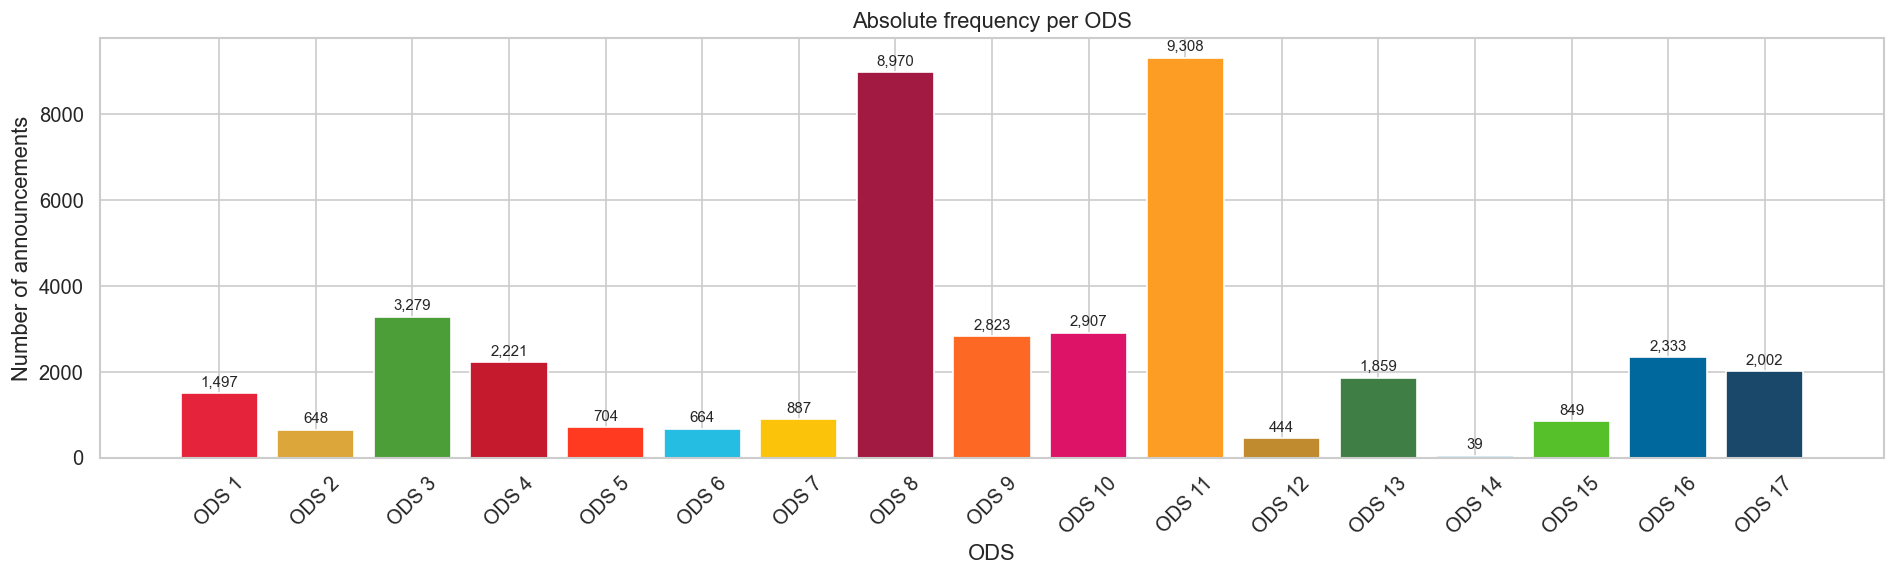

In [ ]:
label_counts = df[ODS_ALL].sum()
label_freq   = label_counts / len(df) * 100

fig, ax = plt.subplots(figsize=(16, 5))

bars = ax.bar(
    label_counts.index,
    label_counts.values,
    color=[ODS_COLORS[ods] for ods in label_counts.index]
)

# Add count label on top of each bar
for bar, count in zip(bars, label_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + label_counts.max() * 0.01,
        f'{int(count):,}',
        ha='center', va='bottom', fontsize=9
    )

ax.set_title('Absolute frequency per ODS')
ax.set_xlabel('ODS')
ax.set_ylabel('Number of announcements')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_DIR_EDA + 'eda_label_distribution.png', bbox_inches='tight')
plt.show()

In [4]:
label_sorted = label_counts.sort_values(ascending=False)
print('Top 5 most frequent ODS:')
print(label_sorted.head())
print('\nTop 5 least frequent ODS:')
print(label_sorted.tail())

Top 5 most frequent ODS:
ODS 11    9308
ODS 8     8970
ODS 3     3279
ODS 10    2907
ODS 9     2823
dtype: int64

Top 5 least frequent ODS:
ODS 5     704
ODS 6     664
ODS 2     648
ODS 12    444
ODS 14     39
dtype: int64


### **2. Multilabel Complexity Metrics**

Standard classification metrics assume each sample has exactly one label. In a multilabel setting, we need specific measures to quantify the complexity of the label space:

- **Label Cardinality (LC):** Average number of labels per announcement. A value of 1 would mean every announcement has exactly one ODS; higher values indicate more multi-assignment.
- **Label Density (LD):** LC normalized by the total number of labels (17). Ranges from 0 to 1; values close to 0 indicate a sparse label space.
- **Unique labelsets:** Number of distinct label combinations present in the dataset. A high number relative to the dataset size makes Label Powerset approaches harder to apply.
- **Proportion of unique labelsets:** Ratio of unique labelsets to total announcements. Values close to 1 mean almost every announcement has a unique combination.

In [5]:
# Label cardinality: average number of labels per announcement
labels_per_sample = Y.sum(axis=1)
label_cardinality = labels_per_sample.mean()

# Label density: cardinality normalized by total number of ODS
label_density = label_cardinality / len(ODS_ALL)

# Proportion of unique labelsets
labelsets = [tuple(row) for row in Y]
n_unique_labelsets = len(set(labelsets))
prop_unique = n_unique_labelsets / len(df)

print('=== Multilabel Complexity Metrics ===')
print(f'Label Cardinality (LC):          {label_cardinality:.4f}')
print(f'Label Density (LD):              {label_density:.4f}')
print(f'Unique labelsets:                {n_unique_labelsets}')
print(f'Proportion of unique labelsets:  {prop_unique:.4f}')
# print(f'Announcements without labels:    {(labels_per_sample < 1).sum()}')
print(f'Announcements with 1 label:      {(labels_per_sample == 1).sum()}')
print(f'Announcements with 2+ labels:    {(labels_per_sample > 1).sum()}')
print(f'Max labels in one announcement:  {labels_per_sample.max()}')

=== Multilabel Complexity Metrics ===
Label Cardinality (LC):          1.1665
Label Density (LD):              0.0686
Unique labelsets:                1043
Proportion of unique labelsets:  0.0294
Announcements with 1 label:      9484
Announcements with 2+ labels:    9800
Max labels in one announcement:  17


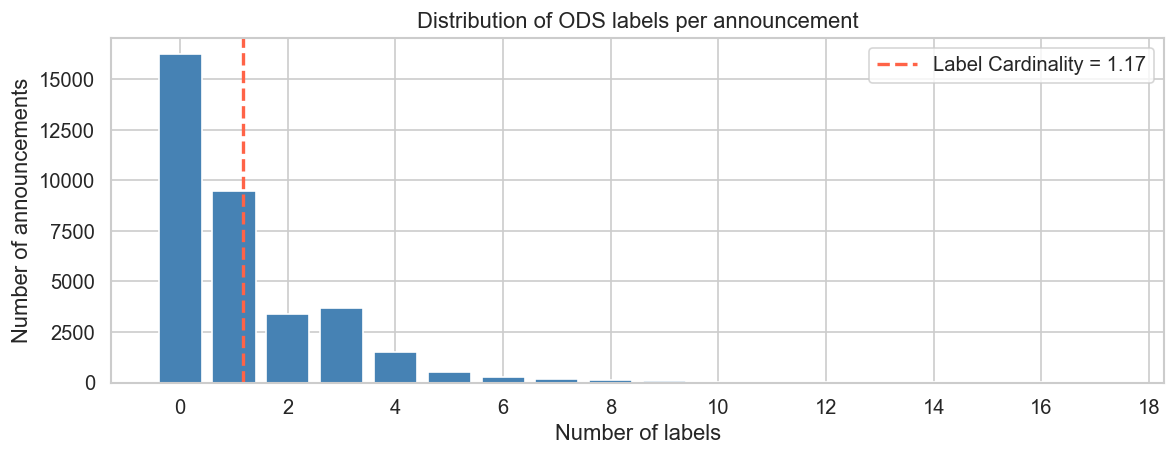

In [ ]:
# Distribution of number of labels per announcement
fig, ax = plt.subplots(figsize=(10, 4))
counts = pd.Series(labels_per_sample).value_counts().sort_index()
ax.bar(counts.index, counts.values, color='steelblue', edgecolor='white')
ax.axvline(label_cardinality, color='tomato', linewidth=2, linestyle='--',
           label=f'Label Cardinality = {label_cardinality:.2f}')
ax.set_title('Distribution of ODS labels per announcement')
ax.set_xlabel('Number of labels')
ax.set_ylabel('Number of announcements')
ax.legend()
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.savefig(OUTPUT_DIR_EDA + 'eda_labels_per_sample.png', bbox_inches='tight')
plt.show()

### **3. Text Length Analysis**

The length of the input text directly affects model choice and tokenization strategy. Very short texts may lack enough semantic content for classification, while very long texts may exceed the maximum sequence length of Transformer models (typically 512 tokens for BERT-based models).

This section measures length in both characters and words, and flags announcements that are suspiciously short — which may indicate PDF extraction or OCR failures.

In [7]:
df['text_len_chars'] = df[Metadata.FULL_TEXT].str.len()
df['text_len_words'] = df[Metadata.FULL_TEXT].str.split().str.len()

print('=== Text Length Statistics ===')
print(df[['text_len_chars', 'text_len_words']].describe().round(1))

=== Text Length Statistics ===
       text_len_chars  text_len_words
count         35520.0         35520.0
mean          14170.8          2218.0
std           41012.1          6344.2
min              37.0             4.0
25%            1426.8           224.0
50%            2754.5           434.0
75%            9554.5          1515.0
max         1444211.0        202135.0


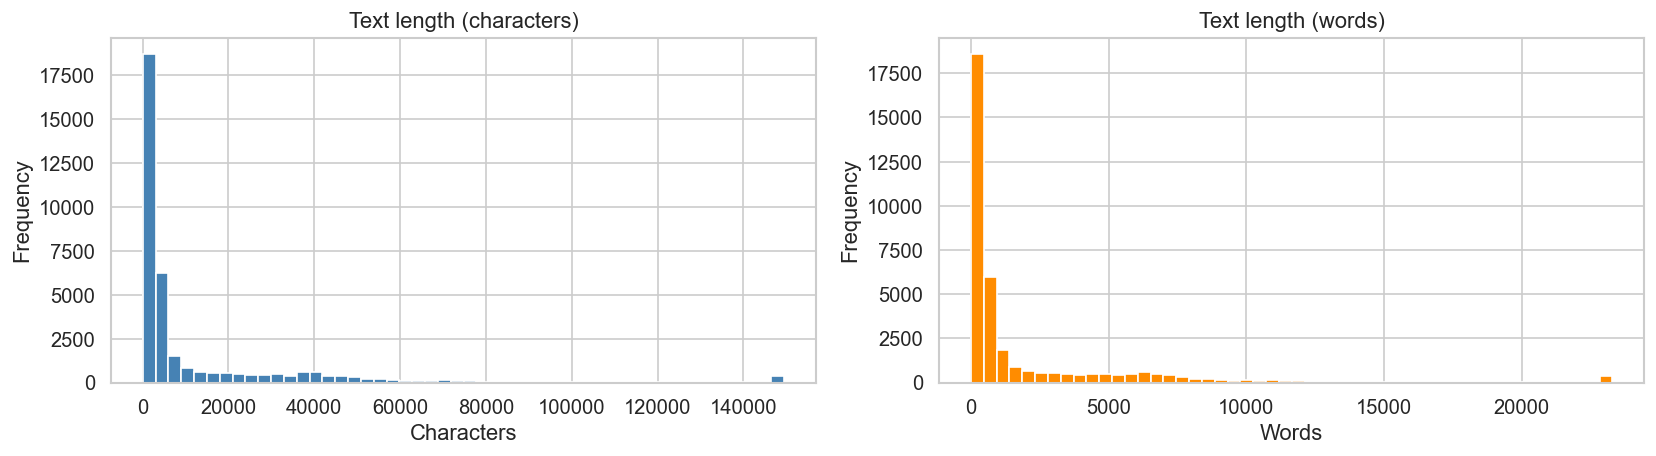

Announcements with fewer than 50 words: 0.4% — possible OCR errors


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribution by characters (clipped at P99 to avoid extreme outliers skewing the plot)
axes[0].hist(df['text_len_chars'].clip(upper=df['text_len_chars'].quantile(0.99)),
             bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Text length (characters)')
axes[0].set_xlabel('Characters')
axes[0].set_ylabel('Frequency')

# Distribution by words (clipped at P99)
axes[1].hist(df['text_len_words'].clip(upper=df['text_len_words'].quantile(0.99)),
             bins=50, color='darkorange', edgecolor='white')
axes[1].set_title('Text length (words)')
axes[1].set_xlabel('Words')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig(OUTPUT_DIR_EDA + 'eda_text_length.png', bbox_inches='tight')
plt.show()

# Flag short texts as potential PDF extraction errors
short_threshold = 50
pct_short = (df['text_len_words'] < short_threshold).mean() * 100
print(f'Announcements with fewer than {short_threshold} words: {pct_short:.1f}% — possible OCR errors')

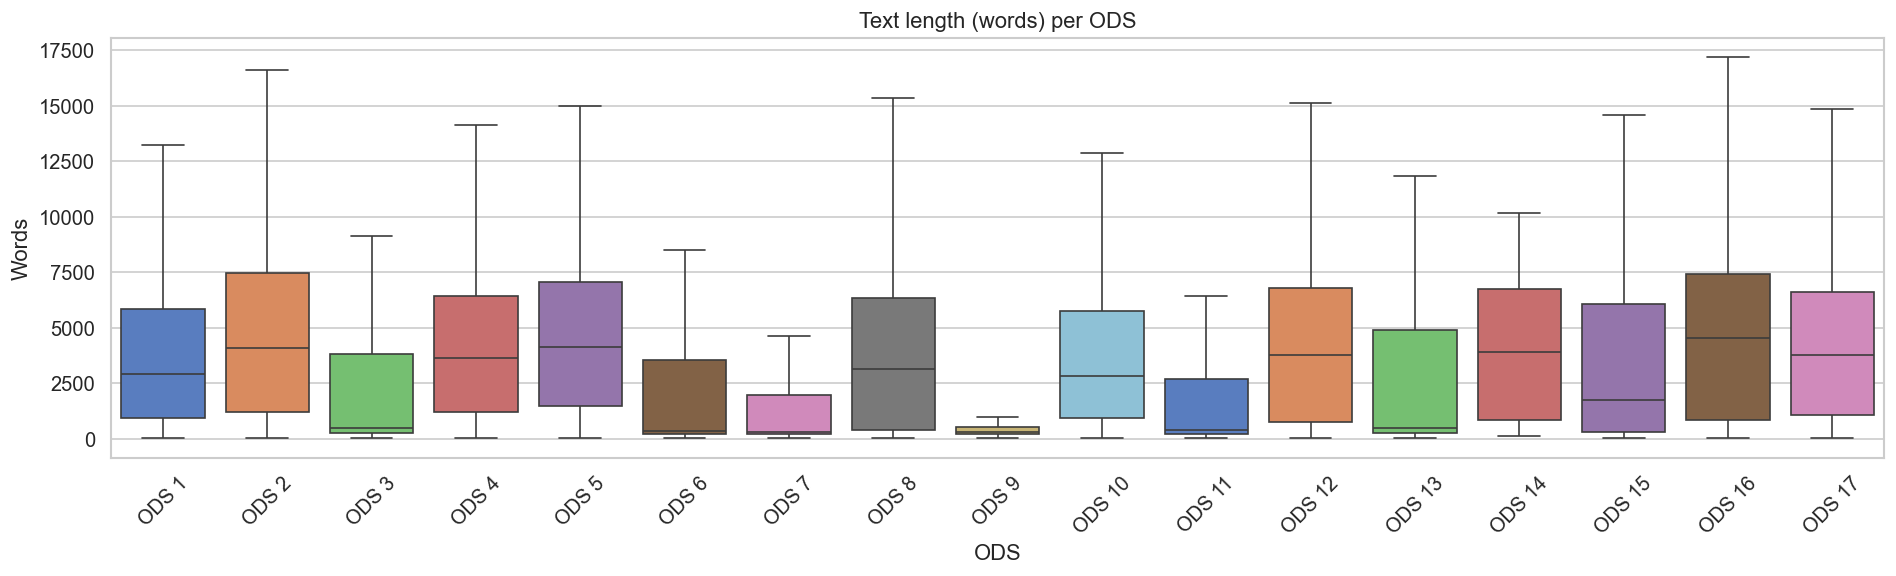

In [ ]:
# Text length per ODS (boxplot)
records = []
for ods in ODS_ALL:
    subset = df[df[ods] == 1]['text_len_words']
    for v in subset:
        records.append({'ODS': ods, 'Words': v})
df_box = pd.DataFrame(records)

fig, ax = plt.subplots(figsize=(16, 5))
sns.boxplot(data=df_box, x='ODS', y='Words', ax=ax,
            order=ODS_ALL, palette='muted',
            showfliers=False)   # Hide extreme outliers for readability
ax.set_title('Text length (words) per ODS')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_DIR_EDA + 'eda_text_length_per_ods.png', bbox_inches='tight')
plt.show()

### **4. ODS Label Co-occurrence**

Co-occurrence analysis reveals which ODS tend to appear together in the same announcement. This is relevant for two reasons:
1. it exposes semantic relationships between ODS in the context of public administration, and
2. it informs the choice of multilabel strategy — high co-occurrence between specific pairs may make Classifier Chains more effective than Binary Relevance, since chains can explicitly model label dependencies.

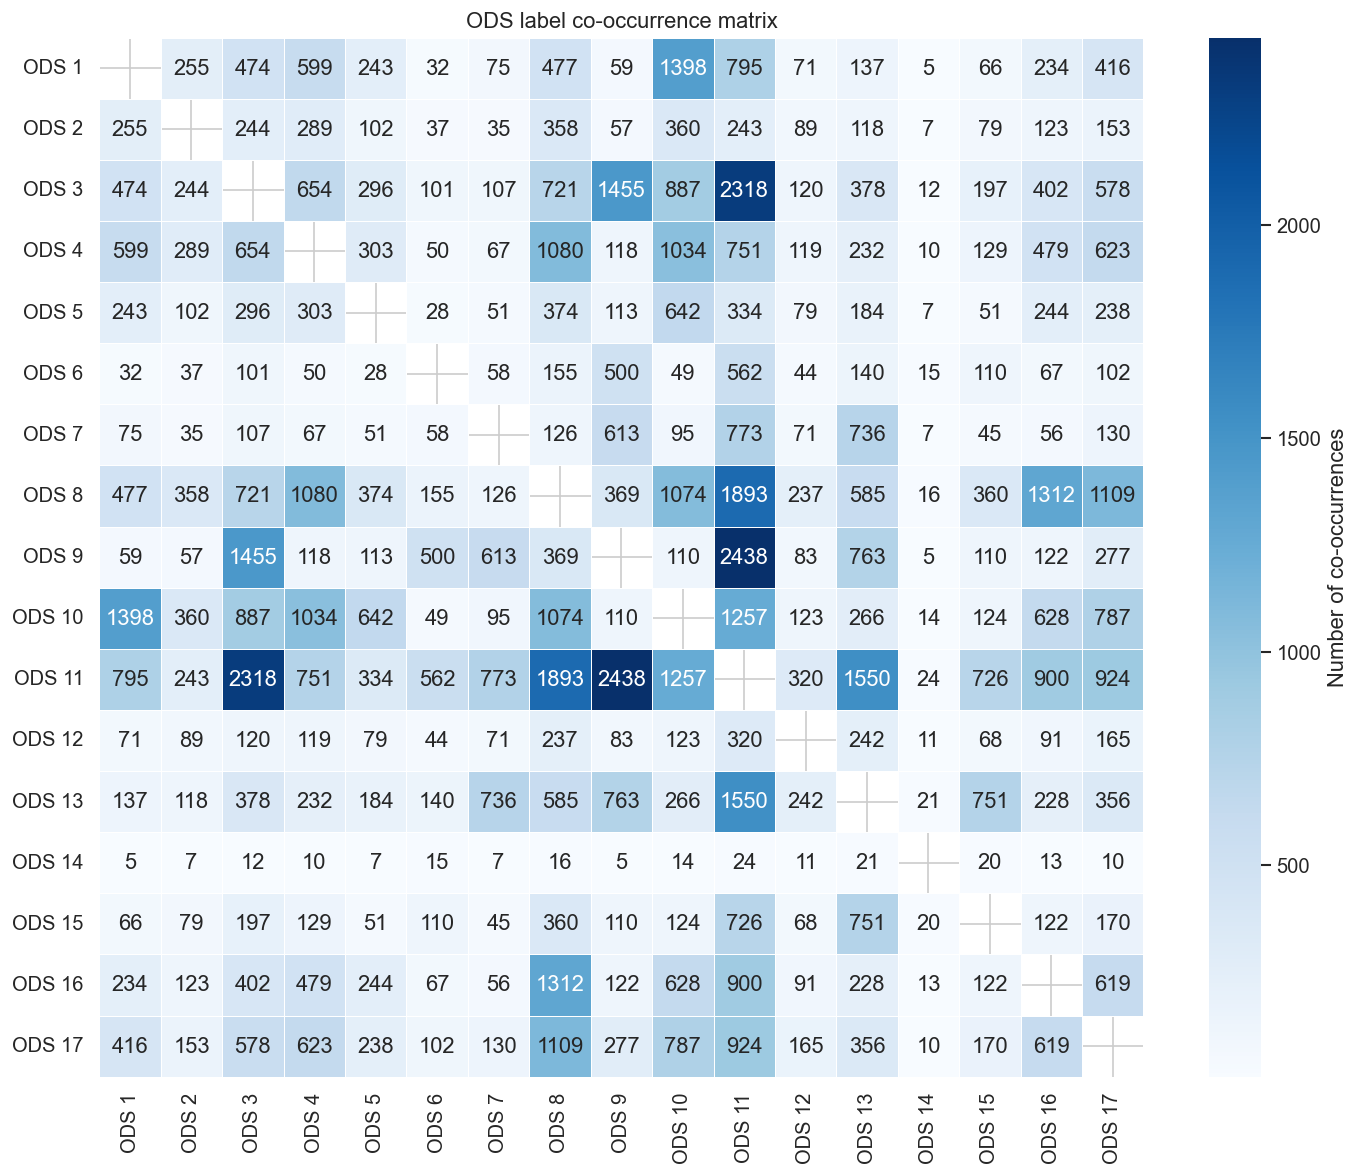

In [ ]:
# Co-occurrence matrix
co_matrix = pd.DataFrame(Y, columns=ODS_ALL).T.dot(pd.DataFrame(Y, columns=ODS_ALL))

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.eye(len(ODS_ALL), dtype=bool)  # Hide diagonal (self-co-occurrence)
sns.heatmap(
    co_matrix, annot=True, fmt='d', cmap='Blues',
    mask=mask, linewidths=0.5, ax=ax,
    cbar_kws={'label': 'Number of co-occurrences'}
)
ax.set_title('ODS label co-occurrence matrix')
plt.tight_layout()
plt.savefig(OUTPUT_DIR_EDA + 'eda_cooccurrence_matrix.png', bbox_inches='tight')
plt.show()

In [11]:
# Top ODS pairs that co-occur most frequently
pair_counts = Counter()
for _, row in df.iterrows():
    labels = [ods for ods in ODS_ALL if row[ods] == 1]
    for pair in combinations(sorted(labels), 2):
        pair_counts[pair] += 1

print('Top 10 most frequent ODS co-occurring pairs:')
for pair, cnt in pair_counts.most_common(10):
    print(f'  {pair[0]} + {pair[1]}: {cnt}')

Top 10 most frequent ODS co-occurring pairs:
  ODS 11 + ODS 9: 2438
  ODS 11 + ODS 3: 2318
  ODS 11 + ODS 8: 1893
  ODS 11 + ODS 13: 1550
  ODS 3 + ODS 9: 1455
  ODS 1 + ODS 10: 1398
  ODS 16 + ODS 8: 1312
  ODS 10 + ODS 11: 1257
  ODS 17 + ODS 8: 1109
  ODS 4 + ODS 8: 1080


### **5. Text Quality & OCR Artefact Detection**

The text in this dataset was extracted from PDF documents, which can introduce noise: garbled characters, encoding errors, or non-standard symbols from imperfect OCR. The presence of non-ASCII characters beyond standard accented letters used in Catalan and Spanish is used here as a proxy for extraction quality.

A high non-ASCII ratio in a document suggests it may contain OCR artefacts that could hurt model performance by introducing out-of-vocabulary tokens or corrupting semantic content.

In [12]:
# Non-ASCII character ratio as a proxy for OCR artefacts
def non_ascii_ratio(text: str) -> float:
    """Returns the proportion of non-ASCII characters in a string."""
    if not text:
        return 0.0
    non_ascii = sum(1 for c in text if ord(c) > 127)
    return non_ascii / len(text)

df['non_ascii_ratio'] = df[Metadata.FULL_TEXT].apply(non_ascii_ratio)

print('Non-ASCII character ratio statistics:')
print(df['non_ascii_ratio'].describe().round(4))

# Show examples with high ratio (potential extraction errors)
threshold = df['non_ascii_ratio'].quantile(0.95)
print(f'\nAnnouncements with ratio > {threshold:.4f} (top 5%):')
suspicious = df[df['non_ascii_ratio'] > threshold][[Metadata.FULL_TEXT, 'non_ascii_ratio']].head(5)
for _, row in suspicious.iterrows():
    print(f'  [{row["non_ascii_ratio"]:.3f}] {row[Metadata.FULL_TEXT][:200]}')
    print()

Non-ASCII character ratio statistics:
count    35520.0000
mean         0.0216
std          0.0043
min          0.0004
25%          0.0185
50%          0.0218
75%          0.0242
max          0.0680
Name: non_ascii_ratio, dtype: float64

Announcements with ratio > 0.0285 (top 5%):
  [0.029] aprovació definitiva de les bases per a la cessió mitjançant llicència d ús privatiu temporal per a la gestió del gimnàs municipal. àrea de presidència i drets socials servei desports la regidoria des

  [0.031] aprovació definitiva del projecte de construcció del dipòsit de suports especials de l arxiu del pavelló de suècia. edicte procediment x2021002793 municipal de construcció del dipòsit de suports espec

  [0.038] aprovació inicial del projecte bàsic i d execució de nou aparcament del carrer valència, en la parcel·la delimitada pel carrer valència, avinguda santiga i carrer mossèn camil rossell.

  [0.032] aprovació inicial de la modificació de crèdit núm. 8/2021. ajuntament orís (barcelona) ed

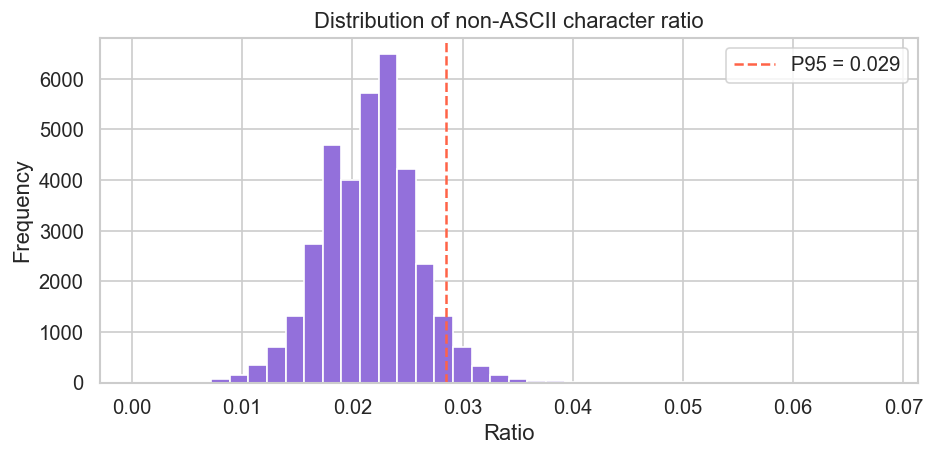

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['non_ascii_ratio'], bins=40, color='mediumpurple', edgecolor='white')
ax.axvline(threshold, color='tomato', linestyle='--', label=f'P95 = {threshold:.3f}')
ax.set_title('Distribution of non-ASCII character ratio')
ax.set_xlabel('Ratio')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR_EDA + 'eda_ocr_quality.png', bbox_inches='tight')
plt.show()

### **6. Summary**

In [ ]:
print('=' * 55)
print('EDA SUMMARY')
print('=' * 55)
print(f'Total announcements:             {len(df):>8,}')
print(f'Total ODS:                       {len(ODS_ALL):>8}')
print(f'Label Cardinality:               {labels_per_sample.mean():>8.3f}')
print(f'Label Density:                   {label_density:>8.4f}')
print(f'Unique labelsets:                {n_unique_labelsets:>8,}')
print(f'Most frequent ODS:               {label_counts.idxmax():>8} ({label_counts.max():,})')
print(f'Least frequent ODS:              {label_counts.idxmin():>8} ({label_counts.min():,})')
print(f'Median text length (words):      {df["text_len_words"].median():>8.0f}')
print(f'Short texts (<50 words):         {(df["text_len_words"] < 50).sum():>8,}')
print('=' * 55)
print('Figures saved to data/processed/:')
print('  - eda_label_distribution.png')
print('  - eda_labels_per_sample.png')
print('  - eda_text_length.png')
print('  - eda_text_length_per_ods.png')
print('  - eda_cooccurrence_matrix.png')
print('  - eda_ocr_quality.png')